In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df = pd.read_excel('/Users/amirmojab/Desktop/ML Course/ml_samples.xlsx', sheet_name='peugeot-206ir-type5')

In [3]:
df['age'] = 1403 - df['production_year']

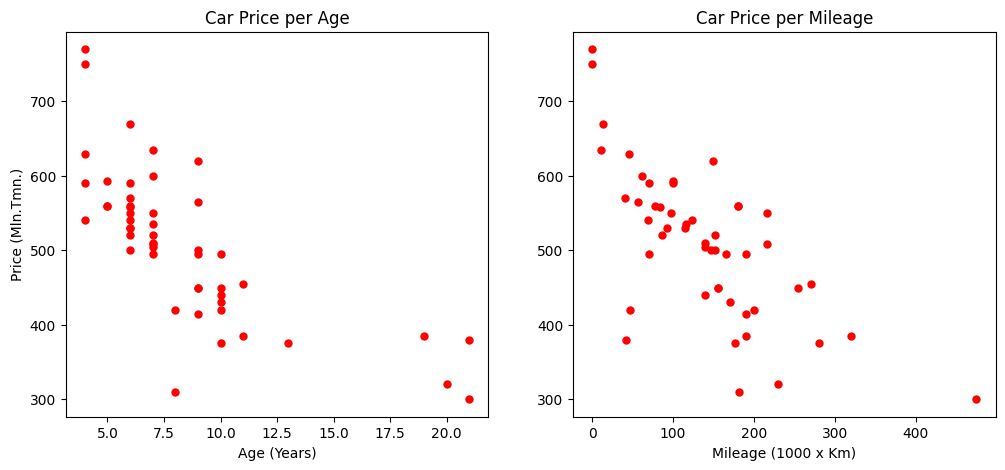

In [4]:
plt.figure(figsize=(12, 5))

ax1 = plt.subplot(1, 2, 1)

ax1.scatter(x=df['age'],
            y=df['price_mln_toman'],
            c='r',
            s=25)

ax2 = plt.subplot(1, 2, 2, sharey=ax1)

ax2.scatter(x=df['mileage_k_km'],
            y=df['price_mln_toman'],
            c='r',
            s=25)

ax1.set_title('Car Price per Age')
ax2.set_title('Car Price per Mileage')

ax1.set_xlabel('Age (Years)')
ax2.set_xlabel('Mileage (1000 x Km)')
ax1.set_ylabel('Price (Mln.Tmn.)')

plt.show()

In [34]:
model_svr_lin = SVR(
    kernel='linear',
    epsilon=0.1,
    # C=1,  # Regularization parameter
)

model_svr_lin.fit(
    X=df[['age', 'mileage_k_km']].to_numpy(),
    y=df['price_mln_toman']
)

SVR(C=1, kernel='linear')

In [35]:
model_svr_lin.predict(np.array([[18, 250]]))

array([334.38863167])

In [36]:
y_pred = model_svr_lin.predict(df[['age', 'mileage_k_km']].to_numpy())
r2 = r2_score(y_true=df['price_mln_toman'].to_numpy().reshape(-1, 1), y_pred=y_pred)
r2

0.6715594207739897